This notebook can be used to generate the main graphs in our paper on mechanotransduction signaling in cells on nanopillars.

First, we introduce the necessary imports and configure our matplotlib settings.

In [2]:
import sys, os, pathlib
sys.path.append("/root/shared/gitrepos/smart-mechanotransduction/utils")
sys.path.append("/root/shared/gitrepos/smart-comp-sci/mechanotransduction-example")
cur_dir = str(pathlib.Path.cwd() / "..")
import smart_analysis
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(f"smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (5,4)})
import numpy as np

This runs data analysis on all simulations in all subfolders within the folder specified by `files_dir` and saves into `npy_dir`. The correct mesh must be included in a subfolder of `mesh_dir`.

In [ ]:
import re
mesh_dir = "/root/shared/gitrepos/smart-nanopillars/meshes/nanopillars_baseline"
files_dir = "/root/scratch/revision_coupled_nuc_sims/results_nanopillars_sweepForce_2026-08-25"
npy_dir = pathlib.Path.cwd() / ".." / "analysis_data" / "npy-files-revisionForceSweep"
npy_dir.mkdir(exist_ok=True)
test_folders = os.listdir(files_dir)
condition_str = []
for i in range(len(test_folders)):
    mesh_file = f"{files_dir}/{test_folders[i]}/mesh/nuc_mesh.h5"
    # for folder in os.listdir(mesh_dir):
    #     if folder[12:] in test_folders[i]: # mesh name matches current case
    #         mesh_file = f"{mesh_dir}/{folder}/spreadCell_mesh.h5"
    #         break
    # if mesh_file == "":
    #     print("Mesh could not be found, skipping to next case")
    #     condition_str.append("")
    #     continue
    # if not (("force400.0" in test_folders[i] or "force0.0" in test_folders[i]) and 
    #         "diff0.001" in test_folders[i]):
    #     continue
    results_folder = f"{files_dir}/{test_folders[i]}"
    condition_cur = test_folders[i]
    condition_str.append(condition_cur)
    if mesh_file=="" or results_folder=="":
        raise ValueError("Folders do not match expected structure for analysis")
    height = 1.04
    zmax_nuc = height + 4.1*2
    tests = ["center_low"]#,"center_high"] # other spatial domains could be specified here
    center_low = [-1, -1, 0, 1, 1, height+1]
    center_high = [-1, -1, zmax_nuc-1.0, 1, 1, zmax_nuc+10]
    domains = [center_low, center_high]
    for sd in range(len(tests)):
        # try:
        tVec, results_all = smart_analysis.analyze_all(
                mesh_file=mesh_file, results_path=results_folder, display=False, axisymm=False,
                subdomain=domains[sd], jacobians=True)
        #     print("error in analysis, skipping to next case")
        # except:
        #     continue
        results_all.insert(0, tVec) # add time as first element in list
        max_length = len(tVec)
        for j in range(len(results_all)):
            if len(results_all[j]) > max_length:
                max_length = len(results_all[j])
        for j in range(len(results_all)):
            num_zeros = max_length - len(results_all[j])
            for k in range(num_zeros):
                results_all[j].append(0)
        np.save(npy_dir / f"{condition_cur}_results_{tests[sd]}.npy", results_all)

Generate graphs of YAP/TAZ N/C over time for cells on different nanopillar substrates (Fig 2D) and store relevant steady-state concentrations.

In [ ]:
from smart import mesh_tools
import dolfin as d

# laminDiff = 0.001 # or .01
# pitchArray=[0.0, 1.5, 3.0, 1.5, 3.0]
# radiusArray=[0.0, 0.2, 0.2, 0.5, 0.5]
# forceArray=[0.0, 400.0, 400.0, 800.0, 800.0, 0.0, 400.0, 400.0, 800.0, 800.0]
# t0Array=[100.0, 100.0, 1000.0, 100.0, 1000.0, 100.0, 100.0, 1000.0, 100.0, 1000.0]
# actinArray=[0.0, 0.0, 0.0, 0.0, 0.0, 20.0, 20.0, 20.0, 20.0, 20.0]
pitchArray = [0.0, 3.0, 3.0]
radiusArray = [0.0, 0.2, 0.5]
substrate_names = ["flat", "200 nm NP", "500 nm NP"]
forceArray = [0.0, 100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0]
var_names_saved = ["aNPC", "FActin", "J_NE", "J_Nuc", "LaminA", "LaminAp", "NE_alt_udef", "NE_udef", 
                   "NPC", "NPC_A", "Nuc_udef", "rupture_marker", "YAPTAZ_nuc"]
plot_names = ["YAPTAZ_nuc", "LaminA", "LaminAp", "rupture_marker", "NPC_A"]
results_idx_ref = []
for name in plot_names:
    results_idx_ref.append(var_names_saved.index(name) + 1) # add one because time is first el

YAPTAZ_ratios = np.zeros([len(pitchArray),len(forceArray)])
vol_vals = np.zeros([len(pitchArray),len(forceArray)])
sa_vals = np.zeros([len(pitchArray),len(forceArray)])
vol_data = [[],[],[]]

plotDyn = False
if plotDyn:
    matplotlib.rcParams.update({'figure.figsize': (6,8)})
else:
    # matplotlib.rcParams.update({'figure.figsize': (3.5,4)})
    matplotlib.rcParams.update({'figure.figsize': (5,4)})

for phiE in [0,2]:
    for i in range(len(pitchArray)):
        for j in range(len(forceArray)):
            if phiE==1:
                results_idx = results_idx_ref
                cur_folder = (f"/root/scratch/new_coupled_sims/results_nanopillars_sweepForce_2026-01-31_scalept2_phiE/"
                            f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                            f"force{forceArray[j]}")#_t0{t0Array[j]}_diff{laminDiff}_actin{actinArray[j]}")
                file_cur = (f"{cur_dir}/analysis_data/npy-files-sweepForce-phiE-submission/"#_newPhos_scalept2_phiE_newAdvectAndDiffuse/"#nuc-mechanics-coupled-corrected/"
                    f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                    f"force{forceArray[j]}_results_all.npy")#t0{t0Array[j]}_diff{laminDiff}_actin{actinArray[j]}_results_all.npy")
            elif phiE==0:
                results_idx = results_idx_ref
                cur_folder = (f"/root/scratch/new_coupled_sims/results_nanopillars_sweepForce_2026-01-31_scalept2/"
                            f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                            f"force{forceArray[j]}")#_t0{t0Array[j]}_diff{laminDiff}_actin{actinArray[j]}")
                file_cur = (f"{cur_dir}/analysis_data/npy-files-sweepForce-submission/"#nuc-mechanics-coupled-corrected/"
                    f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                    f"force{forceArray[j]}_results_all.npy")#t0{t0Array[j]}_diff{laminDiff}_actin{actinArray[j]}_results_all.npy")
            elif phiE==2:
                results_idx = np.array(results_idx_ref)-1
                cur_folder = (f"/root/scratch/new_coupled_sims/results_nanopillars_sweepForce_2026-01-31_scalept2_noStretchSens/"
                            f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                            f"force{forceArray[j]}")#_t0{t0Array[j]}_diff{laminDiff}_actin{actinArray[j]}")
                file_cur = (f"{cur_dir}/analysis_data/npy-files-sweepForce-noStretchSens-submission/"#nuc-mechanics-coupled-corrected/"
                    f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                    f"force{forceArray[j]}_results_all.npy")#t0{t0Array[j]}_diff{laminDiff}_actin{actinArray[j]}_results_all.npy")
            # loaded_cur = mesh_tools.load_mesh(pathlib.Path(f"{cur_folder}/mesh/nuc_mesh.h5"))
            YAPTAZ_cur = np.loadtxt(pathlib.Path(f"{cur_folder}/YAPTAZ.txt"))
            vol_inner = np.loadtxt(pathlib.Path(f"{cur_folder}/mech_data/vol_inner.txt"))
            vol = np.loadtxt(pathlib.Path(f"{cur_folder}/mech_data/vol.txt"))
            sa_inner = np.loadtxt(pathlib.Path(f"{cur_folder}/mech_data/inner_SA.txt"))
            sa_outer = np.loadtxt(pathlib.Path(f"{cur_folder}/mech_data/outer_SA.txt"))
            
            results_cur = np.load(file_cur)
            YAPnuc = results_cur[results_idx[0]]
            if radiusArray[i] == 0.0:
                FActin0 = 140
            elif radiusArray[i] <= 0.15:
                FActin0 = 80.0
            elif radiusArray[i] <= 0.25:
                FActin0 = 100.0
            elif radiusArray[i] <= 0.5:
                FActin0 = 120.0
            else:
                FActin0 = 140.0
            Myo_A = 4.0
            K_CN = 4.0
            K_CY = 5.429e-3
            phiNP = (K_CN + K_CY*FActin0*Myo_A)/(1+ K_CN + K_CY*FActin0*Myo_A)
            YAPcyto = YAPTAZ_cur[:,1]/phiNP
            maxIdx = min([len(YAPnuc),len(YAPcyto)])
            YAPratio = YAPnuc[0:maxIdx] / YAPcyto[0:maxIdx]
            LaminA = results_cur[results_idx[1]]
            YAPTAZ_ratios[i,j] = YAPratio[-1]
            vol_vals[i,j] = vol_inner[-1]
            sa_vals[i,j] = sa_inner[-1]
            # plt.plot(results_cur[0], YAPratio,
            #         label=f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_force{forceArray[j]}")#_t0{t0Array[j]}_actin{actinArray[j]}")
            start_vol = len(vol) - len(YAPratio)
            vol_tot = (vol[start_vol:]+vol_inner[start_vol+1:])
            if j == 0:
                YAPnuc_ref = YAPnuc[-1]
            # print(YAPratio[0])
            # print(vol_tot[0])
            if plotDyn:
                plt.subplot(411)
                plt.semilogx(results_cur[0], vol_tot)#YAPratio[0]*(vol_tot[0]/vol_tot),'--')
                plt.ylabel('Nuclear volume')
                plt.xlim([1, 10000])
                plt.subplot(412)
                plt.semilogx(results_cur[0], sa_outer[start_vol:])
                plt.ylabel('NE area')
                plt.xlim([1, 10000])
                plt.subplot(413)
                plt.semilogx(results_cur[0], results_cur[results_idx[4]])
                plt.ylabel('Active NPC')
                plt.xlim([1, 10000])
                plt.subplot(414)
                plt.semilogx(results_cur[0], results_cur[results_idx[0]])
                plt.ylabel('YAP/TAZ')
                plt.xlim([1, 10000])
            print(f"{i},{j}")
        # plt.plot(vol_vals[i,:], sa_vals[i,:], 'o', label=substrate_names[i])
        if not plotDyn:
            if phiE == 0:
                plt.plot(vol_vals[i,:]/150.7, YAPTAZ_ratios[i,:], 'o', fillstyle='none', label=substrate_names[i])
            elif phiE == 1:
                plt.plot(vol_vals[i,:]/150.7, YAPTAZ_ratios[i,:], 'o', label=substrate_names[i])
            elif phiE == 2:
                plt.plot(vol_vals[i,:]/150.7, YAPTAZ_ratios[i,:], 's', fillstyle='none', label=substrate_names[i])
        vol_NE = np.average(vol)
        vol_cell = 1024#vol_vals[i,0] + 437*2 #1024
        Nconv = 602.2
        NY_tot = 540000#Nconv*(0.9*437*2 + 0.7*150)#(vol_vals[i,0]))#533900
        # NY_nuc = YAPnuc_ref*(vol_vals[i,0])*Nconv # initial value to number
        # YAPpred = ((vol_cell - vol_vals[i,:])/(vol_vals[i,:])) * (NY_nuc / (NY_tot - NY_nuc))
        # plt.plot(vol_vals[i,:]/154.4, YAPpred, label=substrate_names[i])
        # plt.plot(forceArray, vol_vals[i,:], 'o', label=substrate_names[i])
    vol_data[phiE] = vol_vals.copy()
# plt.legend()
# plt.ylabel("YAP/TAZ N/C")
# plt.xlabel('Time (s)')
koushki_data = np.loadtxt("koushki_data.txt")
if not plotDyn:
    # plt.plot(koushki_data[:,0]/2136.114733, koushki_data[:,2], 'x', label="Koushki et al 2023")
    plt.xlim([0.45, 1.05])
    plt.ylim([0.55, 1.5])
    plt.xlabel('Relative volume')
    plt.ylabel('YAP/TAZ N/C')
plt.legend()
plt.savefig("YAPTAZCorr_noStretchSens.pdf", format="pdf")

In [ ]:
plt.plot(forceArray, vol_data[1][0,:]-vol_data[0][0,:])
plt.plot(forceArray, vol_data[2][0,:]-vol_data[0][0,:])
plt.plot(forceArray, vol_data[1][1,:]-vol_data[0][1,:])
plt.plot(forceArray, vol_data[2][1,:]-vol_data[0][1,:])
plt.plot(forceArray, vol_data[1][2,:]-vol_data[0][2,:])
plt.plot(forceArray, vol_data[2][2,:]-vol_data[0][2,:])

Max force per lamin is 0.8287106855612196 at time 9997.21484375
Max force per lamin is 1.051560737399754 at time 193.26641845703125
Max force per lamin is 0.8283638997467435 at time 10000.0


ROOT -2026-09-21 16:09:39,456 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,457 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-21 16:09:39,458 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,460 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,461 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,462 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-21 16:09:39,463 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,464 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-21 16:09:39,464 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-21 16:09:39,465 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,469 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-21 16:09:39,471 fontTools

Max force per lamin is 1.6077956916618201 at time 608.3238525390625


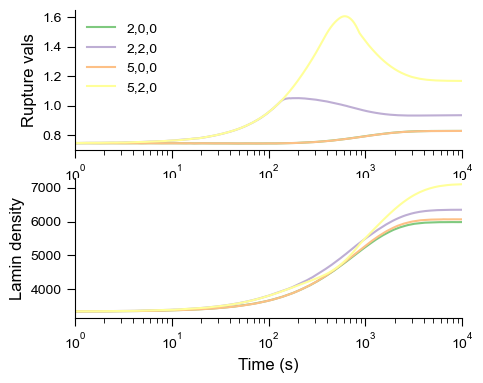

In [40]:
from smart import mesh_tools
import dolfin as d
import h5py

pitchArray=[0.0, 2.0, 3.0, 4.0, 5.0, 6.0]
radiusArray=[0.0, 0.2, 0.2, 0.2, 0.2, 0.2]
forceArray=[0.0, 400.0, 400.0, 800.0, 800.0]
t0Array=[100.0, 100.0, 1000.0, 100.0, 1000.0]
diffArray=[0.0, 0.001, 0.01, 0.1, 0]
actinArray=[0.0, 2.0, 6.0, 20.0, 60.0]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.colormaps['Accent'].colors)

var_names_saved = ["aNPC", "FActin", "J_NE", "J_Nuc", "LaminA", "LaminAp", "NE_alt_udef", "NE_udef", 
                   "NPC", "NPC_A", "Nuc_udef", "rupture_marker", "YAPTAZ_nuc"]
# var_names_saved = var_names_saved[1:]
plot_names = ["YAPTAZ_nuc", "LaminA", "LaminAp", "rupture_marker", "NPC_A"]
results_idx = []
for name in plot_names:
    results_idx.append(var_names_saved.index(name) + 1) # add one because time is first el

YAPTAZ_ratios = np.zeros([len(pitchArray),len(forceArray),len(diffArray)])
vol_vals = np.zeros([len(pitchArray),len(forceArray),len(diffArray)])
integrated_force = np.zeros([len(pitchArray),len(forceArray),len(diffArray)])
for curStr in ["pt5phiE"]:#,"pt5Lamin"]:
    # if "Lamin" in curStr:
    #     parent_folder = f"/root/scratch/new_coupled_sims/results_nanopillars_{curStr}_2026-01-30_newPhos_phiE"
    # else:
    #     parent_folder = f"/root/scratch/new_coupled_sims/results_nanopillars_{curStr}_2026-01-30_newPhos"
    parent_folder = f"/root/scratch/revision_coupled_nuc_sims/results_nanopillars_sweepForce_2026-09-16_revision_a0_0.5"
    # parent_folder = f"/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLaminCond_h2.5_2026-09-16"
    # parent_folder = f"/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-09-14"
    # parent_folder = f"/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLaminCond_2026-09-02"
    for i in [2,5]:#range(len(pitchArray)):
        for j in [0,2]:#range(len(forceArray)):
            for k in [0]:#range(len(diffArray)):
                # cur_folder = (f"{parent_folder}/nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                #             f"force{forceArray[j]}_t0{t0Array[j]}_diff{diffArray[k]}")#_actin{actinArray[k]}")
                cur_folder = f"{parent_folder}/nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_h3_force{forceArray[j]}"
                # cur_folder = f"{parent_folder}/nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_force{forceArray[j]}_t01000.0_lamin1.0"
                # cur_folder = f"{parent_folder}/nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_force{forceArray[j]}_t01000.0_actin30.0_laminPhos0.001"
                # cur_folder = f"{parent_folder}/nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_force{forceArray[j]}_t0{t0Array[j]}_actin{actinArray[k]}"
                # loaded_cur = mesh_tools.load_mesh(pathlib.Path(f"{cur_folder}/mesh/nuc_mesh.h5"))
                # YAPTAZ_cur = np.loadtxt(pathlib.Path(f"{cur_folder}/YAPTAZ.txt"))
                vol_inner = np.loadtxt(pathlib.Path(f"{cur_folder}/mech_data/vol_inner.txt"))
                pRamp = np.loadtxt(pathlib.Path(f"{cur_folder}/mech_data/pRamp.txt"))
                tvec = np.loadtxt(pathlib.Path(f"{cur_folder}/tvec.txt"))
                # test_mesh_file = d.XDMFFile(f"{cur_folder}/mech_data/u_np_ellipsoid.xdmf")
                # test_mesh = d.Mesh()
                # test_mesh_file.read(test_mesh)
                # test_idx = np.argmax(YAPTAZ_NC) + 8
                # u_file = h5py.File(f"{cur_folder}/mech_data/ulin_np_ellipsoid.h5", 'r')
                # u_array = u_file['VisualisationVector'][f'100'][()]
                # file_cur = (f"{cur_dir}/analysis_data/npy-files-{curStr}-submission/"#nuc-mechanics-coupled-corrected/"
                #             f"nanopillars_r{radiusArray[i]}_p{pitchArray[i]}_"
                #             f"force{forceArray[j]}_t0{t0Array[j]}_diff{diffArray[k]}_results_center_low.npy")#_actin{actinArray[k]}_results_all.npy")
                # results_cur = np.load(file_cur)
                # YAPnuc = results_cur[results_idx[0]]
                # if radiusArray[i] == 0.0:
                #     FActin0 = 140
                # elif radiusArray[i] <= 0.15:
                #     FActin0 = 80.0
                # elif radiusArray[i] <= 0.25:
                #     FActin0 = 100.0
                # elif radiusArray[i] <= 0.5:
                #     FActin0 = 120.0
                # else:
                #     FActin0 = 140.0
                # Myo_A = 4.0
                # K_CN = 4.0
                # K_CY = 5.429e-3
                # phiNP = (K_CN + K_CY*FActin0*Myo_A)/(1+ K_CN + K_CY*FActin0*Myo_A)
                # YAPcyto = YAPTAZ_cur[:,1]/phiNP
                # maxIdx = min([len(YAPnuc),len(YAPcyto)])
                # YAPratio = YAPnuc[0:maxIdx] / YAPcyto[0:maxIdx]
                # LaminA = results_cur[results_idx[1]]
                # YAPTAZ_ratios[i,j,k] = YAPratio[-1]
                # vol_vals[i,j,k] = vol_inner[-1]
                rupture_marker_vals = []
                lamin_vals = []
                rupture_file = h5py.File(f"{cur_folder}/rupture_marker.h5", 'r')
                lamin_file = h5py.File(f"{cur_folder}/LaminA.h5", 'r')
                for idx in range(len(vol_inner)-1):
                    try:
                        rupture_array = rupture_file['VisualisationVector'][f'{idx}'][()]
                        rupture_coords = rupture_file['Mesh'][f'{idx}']['mesh']['geometry'][()]
                        rupture_coord_logic = np.logical_and(np.sqrt(rupture_coords[:,0]**2 + rupture_coords[:,1]**2) < 1.0,
                                               rupture_coords[:,2] < 1.5)
                        lamin_array = lamin_file['VisualisationVector'][f'{idx}'][()]
                    except:
                        break
                    # rupture_marker_vals.append(np.average(rupture_array))
                    rupture_marker_vals.append(np.average(rupture_array[rupture_coord_logic]))
                    lamin_vals.append(np.average(lamin_array[rupture_coord_logic]))
                # plt.plot(results_cur[0], YAPratio,
                #         label=f"{i},{j},{k}")
                # integrated_force[i,j,k] = np.trapz(results_cur[results_idx[3]],results_cur[0])
                integrated_force[i,j,k] = np.trapz(rupture_marker_vals, tvec)
                # print(integrated_force[i][j][k])
                # rupture_marker_vals = results_cur[results_idx[3]]
                print(f"Max force per lamin is {max(rupture_marker_vals)} at time {tvec[np.argmax(rupture_marker_vals)]}")
                plt.subplot(2,1,1)
                plt.semilogx(tvec, rupture_marker_vals,label=f"{i},{j},{k}")
                plt.subplot(2,1,2)
                plt.semilogx(tvec, lamin_vals)
                # plt.semilogx(results_cur[0], lamin_vals,label=f"{i},{j},{k}")
                # plt.semilogx(results_cur[0], results_cur[results_idx[3]],label=f"{i},{j},{k}")
        # plt.plot(vol_vals[i,:]/max(vol_vals[i,:]), YAPTAZ_ratios[i,:], 'o', label=substrate_names[i])

plt.subplot(2,1,1)
plt.legend()
plt.ylabel("Rupture vals")
plt.xlabel('Time (s)')
plt.xlim([1, 10000])
plt.subplot(2,1,2)
plt.ylabel("Lamin density")
plt.xlabel('Time (s)')
plt.xlim([1, 10000])
plt.savefig("p3vsp6_laminAndForce.pdf", format="pdf")

In [ ]:
np_means = {
    'Fast': integrated_force[:,1,1],#-integrated_force[0,1,1],
    'Slow': integrated_force[:,2,1],#-integrated_force[0,2,1],
}
width = 0.4
x = np.arange(len(pitchArray))
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Integrated force per lamin')
ax.set_xticks(x + width/2, pitchArray)#[::2])
ax.set_xlabel('Pitch (µm)')
ax.legend()#loc='upper right')
plt.ylim([0,40000])
plt.savefig("forcePerLamin_lowLamin.pdf", format="pdf")

In [ ]:
var_names_saved = ["Cofilin_NP", "FActin", "GActin", "integrin", "integrin_L", "integrin_LT", "integrin_LTst", "integrin_tot",
                   "LaminA", "ligand", "LIMK_A", "mDia_A", "Myo_A", "NPC_A", "pFAK", "RhoA_GDP", "RhoA_GTP_Contact", "RhoA_GTP_PM", 
                   "ROCK_A", "YAPTAZ", "YAPTAZ_nuc", "YAPTAZ_phos"]
plot_names = ["YAPTAZ_phos", "YAPTAZ", "YAPTAZ_nuc"]
source_folder = "/root/shared/gitrepos/smart-mechanotransduction/analysis_data/npy-files-nuc-mechanics-coupled"
folder_list = os.listdir(source_folder)

for i in range(1,len(folder_list)):#[7, 10, 11, 12, 13, 14]:
    results_cur = np.load(f"{source_folder}/{folder_list[i]}")
    YAPTAZ_nuc = results_cur[10]
    # YAPratio_SS[i][j] = YAPratio[-1]
    # if i == 10:# and np.isclose(wasp_val, 0.01):
    if "p3.0" in folder_list[i]:
        plt.plot(results_cur[0], YAPTAZ_nuc, label=folder_list[i], linestyle="dashed")
    else:
        plt.plot(results_cur[0], YAPTAZ_nuc, label=folder_list[i])

# plt.legend()
plt.ylabel("Nuclear YAP/TAZ")
plt.xlabel('Time (s)')
plt.xlim([0, 1800])
# plt.savefig("cytosolic activation.pdf", format="pdf")

Plot super Gaussian functions used to approximate locations of nanopillars

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots()#subplot_kw={"projection": "3d"})
# ax.view_init(elev=90, azim=0)

# Make data.
X = np.arange(0, 5, 0.01)
Y = np.arange(0, 5, 0.01)
X, Y = np.meshgrid(X, Y)

nucRad1 = 4.1
npSpacing = 2.0
npRad = 0.2 + 0.05
xMax = np.ceil(2*nucRad1 / npSpacing) * npSpacing
xNP = np.arange(0.0, xMax+1e-12, npSpacing)
yNP = np.arange(0.0, xMax+1e-12, npSpacing)
xNP, yNP = np.meshgrid(xNP, yNP)
xNP = xNP.flatten()
yNP = yNP.flatten()
nanopillar_logic = np.zeros_like(X)
for i in range(len(xNP)):
    # nanopillar_logic += exp(-((x[0]+u[0]-xNP[i])**2+(x[1]+u[1]-yNP[i])**2)/(2*npRad**2))
    nanopillar_logic += np.exp(-((X-xNP[i])**2+(Y-yNP[i])**2)**2/(npRad**4))

# Plot the surface.
domains = ax.imshow(nanopillar_logic)
plt.gca().invert_yaxis()
fig.colorbar(domains)#surf, shrink=0.5, aspect=5)

plt.savefig("200nm_domains.pdf", format="pdf")

In [ ]:
# plot cap stress over time
matplotlib.rcParams.update({'figure.figsize': (6,3)})
tVec = np.linspace(0.0, 1000.0)
plt.plot(tVec, (1-np.exp(-tVec/100.0)))
plt.savefig("cap_stress.pdf", format="pdf")

0,0: YAPTAZ is 2.67890479755766, vol is 0.39783147851027784
0,1: YAPTAZ is 2.7171128259860646, vol is 0.39483329774237885
0,2: YAPTAZ is 2.7704017967664534, vol is 0.39166942546814015
0,3: YAPTAZ is 2.836245548986828, vol is 0.3881998787797473
0,4: YAPTAZ is 2.9216835126891056, vol is 0.38493738980919406
0,5: YAPTAZ is 3.031769309775171, vol is 0.38131894901515295
1,0: YAPTAZ is 2.6786207300409415, vol is 0.39782511934351905
1,1: YAPTAZ is 2.739489793741674, vol is 0.39515053806501355
1,2: YAPTAZ is 2.7903763253125873, vol is 0.3919660335892386
1,3: YAPTAZ is 2.84350764026915, vol is 0.38878641284948084
1,4: YAPTAZ is 2.9099539504602574, vol is 0.38556101016381245
1,5: YAPTAZ is 3.0299839408941516, vol is 0.38172324692619974
2,0: YAPTAZ is 2.6583883661218937, vol is 0.39801952608891056
2,1: YAPTAZ is 2.681516261730713, vol is 0.3947891271361404
2,2: YAPTAZ is 2.7785064741340877, vol is 0.39032702144307185
2,3: YAPTAZ is 2.8662779987035356, vol is 0.386769265861196
2,4: YAPTAZ is 2.8718

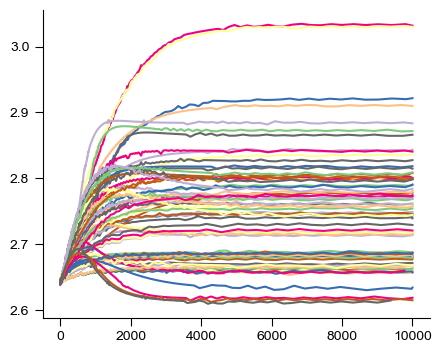

In [51]:
import dolfin as d
import h5py
# plot YAP/TAZ for diff conditions
a0Vec = [0.5, 1.0, 2.0, 0.0]
YAPTAZ_stored = []
AR_stored = []
vol_stored = []
for a in range(len(a0Vec)):
    parent_folder = f"/root/scratch/revision_coupled_nuc_sims/results_nanopillars_sweepForce_2026-09-16_revision_a0_{a0Vec[a]}"
    pitchVec = [0.0, 3.0, 6.0]#, 3.0, 6.0]
    radiusVec = [0.0, 0.2, 0.2]#, 0.5]#, 0.2, 0.2] 
    forceVec = [0.0, 100.0, 200.0, 300.0, 400.0, 500.0]
    YAPTAZ_NCdata = np.zeros((len(pitchVec),len(forceVec)))
    aspectRatioData = np.zeros((len(pitchVec),len(forceVec)))
    volData = np.zeros((len(pitchVec),len(forceVec)))
    load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
    avg_NC_ratio = np.average(load_data[:,2]/load_data[:,4])
    vol_tot = 140 / avg_NC_ratio
    for p in range(len(pitchVec)):
        for f in range(len(forceVec)):
            if "2026-09-02" in parent_folder:
                curFolder = f"{parent_folder}/nanopillars_r{radiusVec[p]}_p{pitchVec[p]}_force{forceVec[f]}_flipAdvDiff"
                tvec = np.loadtxt(f"{curFolder}/tvec.txt")
                YAPTAZ_NC = np.loadtxt(f"{curFolder}/YAPTAZ_NC.txt")
                plt.plot(tvec[0:len(YAPTAZ_NC)], YAPTAZ_NC, '--')
            else:
                curFolder = f"{parent_folder}/nanopillars_r{radiusVec[p]}_p{pitchVec[p]}_h3_force{forceVec[f]}"#_flipAdvDiff"
                tvec = np.loadtxt(f"{curFolder}/tvec.txt")
                if tvec[-1] < 4e3:
                    print(f"Final t is {tvec[-1]}")
                YAPTAZ_NC = np.loadtxt(f"{curFolder}/YAPTAZ_NC.txt")
                plt.plot(tvec[0:len(YAPTAZ_NC)], YAPTAZ_NC)
            YAPTAZ_NCdata[p][f] = YAPTAZ_NC[-1]
            test_mesh_file = d.XDMFFile(f"{curFolder}/mech_data/u_np_ellipsoid.xdmf")
            test_mesh = d.Mesh()
            test_mesh_file.read(test_mesh)
            test_idx = len(YAPTAZ_NC) + 7
            u_file = h5py.File(f"{curFolder}/mech_data/ulin_np_ellipsoid.h5", 'r')
            u_array = u_file['VisualisationVector'][f'{test_idx}'][()]
            deformCoord = test_mesh.coordinates() + u_array
            rvals = np.sqrt(deformCoord[:,0]**2 + deformCoord[:,1]**2)
            aspectRatioData[p][f] = 2*np.max(rvals)/(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2]))
            curVols = np.loadtxt(f"{curFolder}/mech_data/vol_inner.txt")
            relVol = (curVols+10)/vol_tot
            volData[p][f] = relVol[-1]
            print(f"{p},{f}: YAPTAZ is {YAPTAZ_NCdata[p][f]}, vol is {volData[p][f]}")# AR is {aspectRatioData[p][f]}")
    YAPTAZ_stored.append(YAPTAZ_NCdata)
    AR_stored.append(aspectRatioData)
    vol_stored.append(volData)
    # plt.xlim([0, 1000])

ROOT -2026-09-22 22:48:53,865 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,866 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 22:48:53,867 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,870 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,871 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,872 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 22:48:53,875 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,875 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 22:48:53,876 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 22:48:53,878 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,883 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 22:48:53,886 fontTools

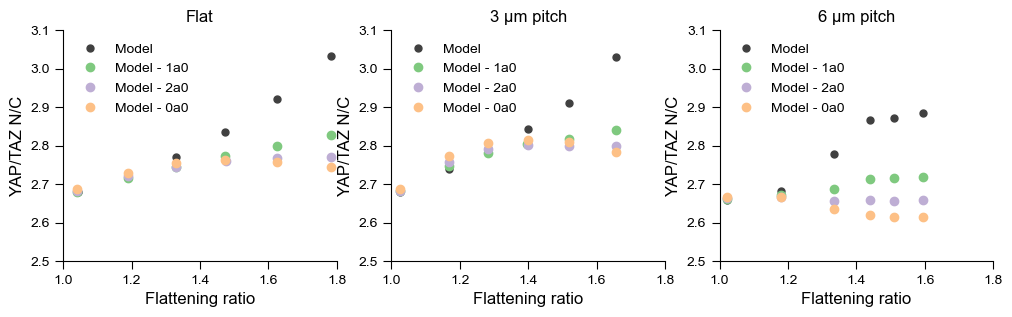

In [54]:
from scipy import stats
# comparison with experiments
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
flatData = load_data[load_data[:,0]==0]
p3Data = load_data[load_data[:,0]==3]
p6Data = load_data[load_data[:,0]==6]
expData = [flatData, p3Data, p6Data]
strData = ["Flat", "3 µm pitch", "6 µm pitch"]
plt.figure(figsize=(12,3))
for i in [0,1,2]:
    plt.subplot(1,3,i+1)
    corr_result = stats.pearsonr(expData[i][:,9], expData[i][:,12])
    r = corr_result[0]
    p_value = corr_result[1]
    # plt.plot(expData[i][:,9], expData[i][:,12], 'x', color=[0,0.5,0], label=f'Exp: r={r:.2f}, p={p_value:.2g}')
    # plt.plot(p3Data[:,9], p3Data[:,12], 'x', label='Exp - p3')
    # plt.plot(p6Data[:,9], p6Data[:,12], 'x', label='Exp - p6')
    plt.plot(AR_stored[0][i,:], YAPTAZ_stored[0][i,:], 'o', color=[0.25,0.25,0.25],label='Model', markersize=5)# - 0.5a0')
    plt.plot(AR_stored[1][i,:], YAPTAZ_stored[1][i,:], 'o', label='Model - 1a0')
    plt.plot(AR_stored[2][i,:], YAPTAZ_stored[2][i,:], 'o', label='Model - 2a0')
    plt.plot(AR_stored[3][i,:], YAPTAZ_stored[3][i,:], 'o', label='Model - 0a0')
    # plt.plot(aspectRatioData[1,:], YAPTAZ_NCdata[1,:], 'o', label = 'Model - p3')
    # plt.plot(aspectRatioData[2,:], YAPTAZ_NCdata[2,:], 'o', label = 'Model - p6')
    plt.xlabel('Flattening ratio')
    plt.ylabel('YAP/TAZ N/C')
    plt.legend(loc='upper left')
    # plt.xlim([0, 3.5])
    # plt.ylim([1, 6])
    plt.xlim([1,1.8])
    plt.ylim([2.5, 3.1])
    plt.title(strData[i])
plt.savefig("yap_flattening.pdf", format="pdf")

ROOT -2026-09-22 20:22:51,768 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,772 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 20:22:51,775 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,783 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,784 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,785 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 20:22:51,796 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,797 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 20:22:51,798 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 20:22:51,800 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,812 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 20:22:51,815 fontTools

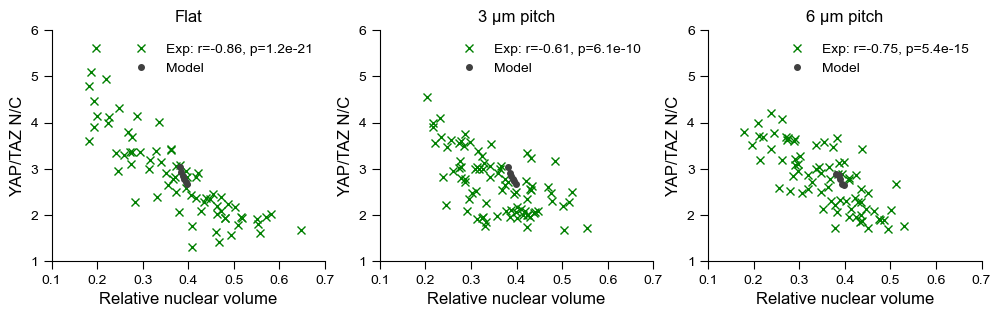

In [52]:
# comparison with experiments
from scipy import stats
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
flatData = load_data[load_data[:,0]==0]
p3Data = load_data[load_data[:,0]==3]
p6Data = load_data[load_data[:,0]==6]
expData = [flatData, p3Data, p6Data]
strData = ["Flat", "3 µm pitch", "6 µm pitch"]
plt.figure(figsize=(12,3))
for i in [0,1,2]:
    plt.subplot(1,3,i+1)
    corr_result = stats.pearsonr(expData[i][:,6], expData[i][:,12])
    r = corr_result[0]
    p_value = corr_result[1]
    plt.plot(expData[i][:,6], expData[i][:,12], 'x', color=[0,0.5,0], label=f'Exp: r={r:.2f}, p={p_value:.2g}')
    plt.plot(vol_stored[0][i,:], YAPTAZ_stored[0][i,:], 'o', color=[0.25,0.25,0.25], label='Model', markersize=4)
    plt.xlabel('Relative nuclear volume')
    plt.ylabel('YAP/TAZ N/C')
    plt.legend(loc='upper right')
    plt.xlim([0.1, 0.7])
    plt.ylim([1, 6])
    plt.title(strData[i])
plt.savefig("yap_vol.pdf", format="pdf")

In [ ]:
# compare deformation of lamin-deficient cells
import dolfin as d
import h5py
# plot YAP/TAZ for diff conditions
parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-07-20"
pitchVec = [0.0, 3.0, 6.0]
radiusVec = [0.0, 0.2, 0.2] 
forceVals = [10.0, 100.0, 200.0, 300.0, 400.0]
t0Val = 1000.0
laminVec = [0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
aspectRatioData = np.zeros((len(pitchVec),len(laminVec),len(forceVals)))
nucRadData = np.zeros((len(pitchVec),len(laminVec),len(forceVals)))
for p in range(len(pitchVec)):
    for l in range(len(laminVec)):
        curFolder = f"{parent_folder}/nanopillars_r{radiusVec[p]}_p{pitchVec[p]}_force400.0_t0{t0Val}_lamin{laminVec[l]}"
        test_mesh_file = d.XDMFFile(f"{curFolder}/mech_data/u_np_ellipsoid.xdmf")
        test_mesh = d.Mesh()
        test_mesh_file.read(test_mesh)
        kRamp = np.loadtxt(f"{curFolder}/mech_data/kRamp.txt")
        u_file = h5py.File(f"{curFolder}/mech_data/ulin_np_ellipsoid.h5", 'r')
        for f in range(len(forceVals)):
            test_idx = np.argmin(np.abs(kRamp-forceVals[f]))#len(kRamp)
            u_array = u_file['VisualisationVector'][f'{test_idx}'][()]
            deformCoord = test_mesh.coordinates() + u_array
            rvals = np.sqrt(deformCoord[:,0]**2 + deformCoord[:,1]**2)
            aspectRatioData[p][l][f] = 2*np.max(rvals)/(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2]))
            nucRadData[p][l][f] = np.max(rvals)
            print(f"{p},{l},{f}: Nuc radius is {nucRadData[p][l][f]}, AR is {aspectRatioData[p][l][f]}")

In [ ]:
# compare with exp data
# plt.plot(laminVec, np.pi*np.power(nucRadData[0][:],2)/90, 'o')
plt.plot(laminVec, np.pi*np.power(nucRadData[1,:,0],2)/90, 'o', label="NP simulations, F=10")
plt.plot(laminVec, np.pi*np.power(nucRadData[1,:,1],2)/90, 'o', label="NP simulations, F=100")
plt.plot(laminVec, np.pi*np.power(nucRadData[1,:,2],2)/90, 'o', label="NP simulations, F=200")
plt.plot(laminVec, np.pi*np.power(nucRadData[1,:,3],2)/90, 'o', label="NP simulations, F=300")
plt.plot(laminVec, np.pi*np.power(nucRadData[1,:,4],2)/90, 'o', label="NP simulations, F=400")
# plt.plot(laminVec, np.pi*np.power(nucRadData[2][:],2)/90, 'o')
load_siLMNA = np.loadtxt('siLMNA-NP-areas.csv', skiprows=1, delimiter=',')
load_control = np.loadtxt('control-NP-areas.csv', skiprows=1, delimiter=',')
# plt.plot(np.average(load_control[:,1])/25, np.average(load_control[:,0])/300, 'x', label="Control NP data")
# plt.plot(np.average(load_siLMNA[:,1])/25, np.average(load_siLMNA[:,0])/300, 'x', label="siLMNA NP data")
x = [np.average(load_control[:,1])/25, np.average(load_siLMNA[:,1])/25]
y = [np.average(load_control[:,0])/300, np.average(load_siLMNA[:,0])/300]
xerr = [np.std(load_control[:,1])/25, np.std(load_siLMNA[:,1])/25]
yerr = [np.std(load_control[:,0])/300, np.std(load_siLMNA[:,0])/300]
plt.errorbar(x, y, yerr, xerr, 'x', capsize=2, label="Experiments")
# plt.ylim([0.5, 1.5])
# plt.xlim([0.25, 1.75])
plt.xlabel('Relative lamin abundance')
plt.ylabel('Normalized nuclear area')
plt.legend()
plt.ylim([0, 1.5])
plt.savefig("lamin_area_corr.pdf", format="pdf")

ROOT -2026-09-05 00:50:56,454 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,455 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-05 00:50:56,455 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,460 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,461 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,462 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-05 00:50:56,464 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,465 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-05 00:50:56,465 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-05 00:50:56,467 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,471 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-05 00:50:56,473 fontTools

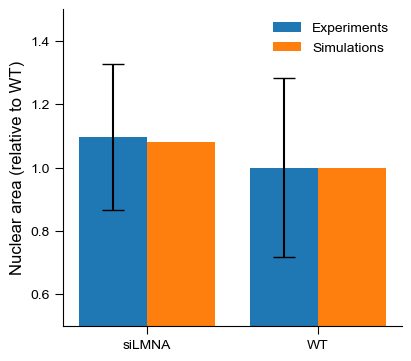

In [95]:
# compare with exp data
load_siLMNA = np.loadtxt('siLMNA-NP-areas.csv', skiprows=1, delimiter=',')
load_control = np.loadtxt('control-NP-areas.csv', skiprows=1, delimiter=',')
expNorm = np.average(load_control[:,0])
expMeans = np.array([np.average(load_siLMNA[:,0])/expNorm, np.average(load_control[:,0])/expNorm])
expData = [load_siLMNA[:,0]/expNorm, load_control[:,0]/expNorm]
expStd = np.array([np.std(load_siLMNA[:,0])/300, np.std(load_control[:,0])/300])
simNorm = np.pi*np.power(nucRadData[1,10,4],2)
simMeans = [np.pi*np.power(nucRadData[1,0,4],2)/simNorm, np.pi*np.power(nucRadData[1,10,4],2)/simNorm]
np_means = {
    'Experiments': np.array(expMeans),
    'Simulations': np.array(simMeans),
}
width = 0.4
x = np.array([0,1])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(4,3.5))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if attribute == "Experiments":
        rects = ax.bar(x + offset, measurement, width, 
                       yerr=expStd, label=attribute)#, hatch='///')
        # for i in range(len(expData)):
        #     randScatter = x[i] + offset + np.random.uniform(-width/4, width/4, size=len(expData[i])) 
        #     ax.scatter(randScatter, expData[i], color="black", s=4)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Nuclear area (relative to WT)')
ax.set_xticks(x+width/2, ['siLMNA', 'WT'])#[::2])
ax.legend()#loc='upper right')
plt.ylim([0.5,1.5])
plt.savefig("lmna_area_corr.pdf", format="pdf")

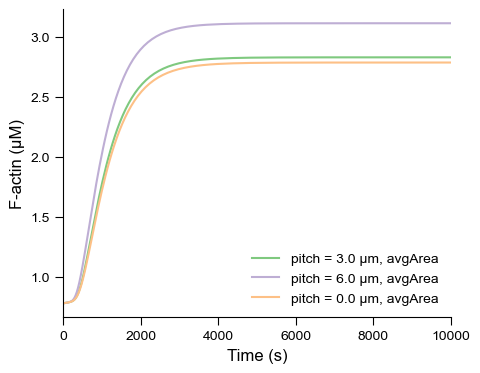

In [44]:
import numpy as np
import matplotlib.pyplot as plt
radiusArray= [0.2, 0.2, 0.0]
pitchArray= [3.0, 6.0, 0.0]
heightArray=[1.5, 1.5, 0.0]
scaleFactor = 0.95#0.82
nucScaleFactor = 0.7#0.8
cytoVol = 4*480/scaleFactor**3
nucVol = (4/3)*np.pi*5.3*5.3*2.4/nucScaleFactor**3
YAPtot = nucVol*0.7 + cytoVol*0.9
YAP_NC_sim = np.ones((3,3))
FActin_sim = np.ones((3,3))
for i in range(len(radiusArray)):
    multStr = ["lowerArea", "avgArea", "upperArea"]#, "noWASP"]
    for j in range(len(multStr)):
        # if multStr[j] == "noWASP":
        #     curFolder = f"/root/scratch/revision_coupled_nuc_sims/aanya_sims/aanya_results_p{pitchArray[i]}_newNuc_avgArea_{multStr[j]}"
        # else:
        curFolder = f"/root/scratch/revision_coupled_nuc_sims/aanya_sims/aanya_results_p{pitchArray[i]}_heightScaling_10xFAK_{multStr[j]}"
        YAPnuc = np.loadtxt(f"{curFolder}/YAPTAZ_nuc.txt")
        YAPcyto = (YAPtot - YAPnuc*nucVol)/cytoVol
        FActin = np.loadtxt(f"{curFolder}/FActin.txt")
        tvec = np.loadtxt(f"{curFolder}/tvec.txt")
        tvec = tvec[0:len(YAPnuc)]
        if multStr[j] == "avgArea":
            plt.plot(tvec, YAPnuc/YAPcyto, label=f"pitch = {pitchArray[i]} µm, {multStr[j]}")
            # plt.plot(tvec, FActin, label=f"pitch = {pitchArray[i]} µm, {multStr[j]}")
        YAP_NC_sim[i][j] = YAPnuc[-1]/YAPcyto[-1]
        FActin_sim[i][j] = FActin[-1]
# plt.ylim([0,3.0])
plt.xlim([0, 10000])
# plt.ylim([10,40])
plt.xlabel('Time (s)')
plt.ylabel('F-actin (µM)')
plt.legend()

ROOT -2026-09-21 16:32:46,414 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,415 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-21 16:32:46,416 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,418 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,418 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,419 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-21 16:32:46,421 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,422 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-21 16:32:46,423 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-21 16:32:46,424 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,428 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-21 16:32:46,429 fontTools

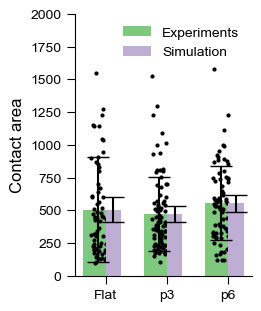

In [41]:
# compare with exp data
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
flatData = load_data[load_data[:,0]==0]
p3Data = load_data[load_data[:,0]==3]
p6Data = load_data[load_data[:,0]==6]
expMeans = np.array([np.average(flatData[:,5]), np.average(p3Data[:,5]), np.average(p6Data[:,5])])
expData = [flatData[:,5], p3Data[:,5], p6Data[:,5]]
expSEM = np.array([np.std(flatData[:,5])/np.sqrt(len(flatData[:,5])), 
                   np.std(p3Data[:,5])/np.sqrt(len(p3Data[:,5])), 
                   np.std(p6Data[:,5])/np.sqrt(len(p6Data[:,5]))])
expStd = np.array([np.std(flatData[:,5]),np.std(p3Data[:,5]),np.std(p6Data[:,5])])
np_means = {
    'Experiments': np.array(expMeans),
    # 'Sim - low area': expMeans-2*expSEM,
    'Simulation': expMeans,
    # 'Sim - high area': expMeans+2*expSEM,
}
width = 0.25
x = np.array([0,1,2])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(2.5,3))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if attribute == "Experiments":
        rects = ax.bar(x + offset, measurement, 2*width, 
                       yerr=expStd, label=attribute)#, hatch='///')
        for i in range(len(expData)):
            randScatter = x[i] + offset + np.random.uniform(-width/2, width/2, size=len(expData[i])) 
            ax.scatter(randScatter, expData[i], color="black", s=4)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute,
                       yerr=2*expSEM)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Contact area')
ax.set_xticks(x + 0.5*width, ['Flat','p3','p6'])#[::2])
ax.legend()#loc='upper right')
plt.ylim([0,2000])
plt.savefig("aanya_area.pdf", format="pdf")

In [ ]:
import numpy as np
from scipy.stats import f_oneway, tukey_hsd
# 1. Define your sample groups (arrays can be different lengths)

group_A = expData[0]
group_B = expData[1]
group_C = expData[2]

# 2. Perform the One-Way ANOVA
anova_stat, anova_p = f_oneway(group_A, group_B, group_C)
print(f"ANOVA result: F-statistic = {anova_stat:.4f}, p-value = {anova_p:.4f}\n")

# 3. Perform Tukey's HSD test if ANOVA p-value is significant (< 0.05)
if anova_p < 0.05:
    res = tukey_hsd(group_A, group_B, group_C)
    print(res)
else:
    print("ANOVA is not statistically significant; post-hoc test not required.")

ANOVA result: F-statistic = 1.2041, p-value = 0.3019

ANOVA is not statistically significant; post-hoc test not required.


ROOT -2026-09-21 16:35:05,800 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,801 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-21 16:35:05,802 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,804 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,804 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,805 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-21 16:35:05,806 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,807 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-21 16:35:05,807 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-21 16:35:05,808 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,812 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-21 16:35:05,814 fontTools

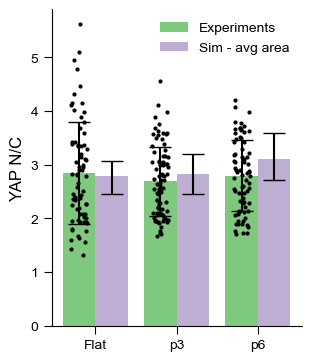

In [45]:
# compare with exp data
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
flatData = load_data[load_data[:,0]==0]
p3Data = load_data[load_data[:,0]==3]
p6Data = load_data[load_data[:,0]==6]
expMeans = [np.average(flatData[:,12]), np.average(p3Data[:,12]), np.average(p6Data[:,12])]
expData = [flatData[:,12], p3Data[:,12], p6Data[:,12]]
# expStd = [2*np.std(flatData[:,12])/np.sqrt(len(flatData[:,12])), 
#           2*np.std(p3Data[:,12])/np.sqrt(len(p3Data[:,12])), 
#           2*np.std(p6Data[:,12])/np.sqrt(len(p6Data[:,12]))]
expStd = [np.std(flatData[:,12]),np.std(p3Data[:,12]),np.std(p6Data[:,12])]
simMeans = [YAP_NC_sim[2][1], YAP_NC_sim[0][1], YAP_NC_sim[1][1]]
simLowerErr = [YAP_NC_sim[2][1]-YAP_NC_sim[2][0], YAP_NC_sim[0][1]-YAP_NC_sim[0][0], YAP_NC_sim[1][1]-YAP_NC_sim[1][0]]
simUpperErr = [YAP_NC_sim[2][2]-YAP_NC_sim[2][1], YAP_NC_sim[0][2]-YAP_NC_sim[0][1], YAP_NC_sim[1][2]-YAP_NC_sim[1][1]]
np_means = {
    'Experiments': np.array(expMeans),
    # 'Sim - low area': YAP_NC_sim[[2,0,1],0],
    'Sim - avg area': YAP_NC_sim[[2,0,1],1],
    # 'Sim - high area': YAP_NC_sim[[2,0,1],2],
    # 'Sim - avg area (no WASP)': YAP_NC_sim[[2,0,1],3],
}
width = 0.4
x = np.array([0,1,2])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(3,3.5))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if attribute == "Experiments":
        rects = ax.bar(x + offset, measurement, width, 
                       yerr=expStd, label=attribute)#, hatch='///')
        for i in range(len(expData)):
            randScatter = x[i] + offset + np.random.uniform(-width/4, width/4, size=len(expData[i])) 
            ax.scatter(randScatter, expData[i], color="black", s=4)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute,
                       yerr=[simLowerErr,simUpperErr])#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('YAP N/C')
ax.set_xticks(x + 0.5*width, ['Flat','p3','p6'])#[::2])
ax.legend()#loc='upper right')
plt.savefig("aanya_yap.pdf", format="pdf")

ROOT -2026-09-21 16:37:14,628 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,629 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-21 16:37:14,631 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,633 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,634 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,635 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-21 16:37:14,635 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,636 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-21 16:37:14,637 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-21 16:37:14,638 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,641 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-21 16:37:14,642 fontTools

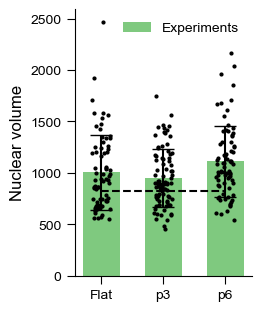

In [47]:
scaleFactor = 0.95#0.82
nucScaleFactor = 0.7#0.8
cytoVol = 4*480/scaleFactor**3
nucVol = (4/3)*np.pi*5.3*5.3*2.4/nucScaleFactor**3
# compare with exp data
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
flatData = load_data[load_data[:,0]==0]
p3Data = load_data[load_data[:,0]==3]
p6Data = load_data[load_data[:,0]==6]
expMeanNucVol = [np.average(flatData[:,2]), np.average(p3Data[:,2]), np.average(p6Data[:,2])]
expMeanCytoVol = [np.average(flatData[:,3]), np.average(p3Data[:,3]), np.average(p6Data[:,3])]
expDataNucVol = [flatData[:,2], p3Data[:,2], p6Data[:,2]]
expDataCytoVol = [flatData[:,3], p3Data[:,3], p6Data[:,3]]
expStdNucVol = [np.std(flatData[:,2]),np.std(p3Data[:,2]),np.std(p6Data[:,2])]
expStdCytoVol = [np.std(flatData[:,3]),np.std(p3Data[:,3]),np.std(p6Data[:,3])]

np_means = {
    'Experiments': np.array(expMeanNucVol),
    # 'Simulations': [nucVol, nucVol, nucVol]
}
width = 0.6
x = np.array([0,1,2])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(2.5,3))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if attribute == "Experiments":
        rects = ax.bar(x + offset, measurement, width, 
                       yerr=expStdNucVol, label=attribute)#, hatch='///')
        for i in range(len(expDataNucVol)):
            randScatter = x[i] + offset + np.random.uniform(-width/4, width/4, size=len(expDataNucVol[i])) 
            ax.scatter(randScatter, expDataNucVol[i], color="black", s=4)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.plot(x, [nucVol,nucVol,nucVol], '--', color='black')
ax.set_ylabel('Nuclear volume')
ax.set_xticks(x, ['Flat','p3','p6'])#[::2])
ax.legend()#loc='upper right')
plt.savefig("aanya_nucvol.pdf", format="pdf")

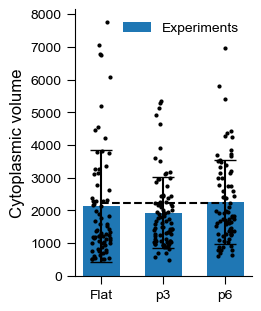

In [6]:
np_means = {
    'Experiments': np.array(expMeanCytoVol),
    # 'Simulations': [cytoVol, cytoVol, cytoVol]
}
width = 0.6
x = np.array([0,1,2])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(2.5,3))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if attribute == "Experiments":
        rects = ax.bar(x + offset, measurement, width, 
                       yerr=expStdCytoVol, label=attribute)#, hatch='///')
        for i in range(len(expDataCytoVol)):
            randScatter = x[i] + offset + np.random.uniform(-width/4, width/4, size=len(expDataCytoVol[i])) 
            ax.scatter(randScatter, expDataCytoVol[i], color="black", s=4)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.plot(x, [cytoVol,cytoVol,cytoVol], '--', color='black')
ax.set_ylabel('Cytoplasmic volume')
ax.set_xticks(x, ['Flat','p3','p6'])#[::2])
ax.legend()#loc='upper right')
plt.savefig("aanya_cytovol.pdf", format="pdf")

In [ ]:
from smart import mesh_tools
import dolfin as d
radiusArray= [
 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
 0.5, 0.25, 0.5, 0.25,
 0.0, 0.0, 0.0, 0.0, 0.0]
pitchArray= [
 5.0, 2.5, 1.0, 5.0, 2.5, 1.0,
 5.0, 2.5, 5.0, 2.5,
 0.0, 0.0, 0.0, 0.0, 0.0]
heightArray=[
 1.0, 1.0, 1.0, 3.0, 3.0, 3.0,
 1.0, 1.0, 3.0, 3.0,
 0.0, 0.0, 0.0, 0.0, 0.0]
cellRadArray=[
 20.25, 18.52, 16.55, 19.93, 18.04, 15.39,
 20.01, 17.45, 18.06, 17.64,
 22.48, 18.08, 15.39, 14.18, 12.33]
EModArray=[
 10000000, 10000000, 10000000, 10000000, 10000000, 10000000, 
 10000000, 10000000, 10000000, 10000000,
 10000000, 14, 7, 3, 1]
yapData = [
 2.697152, 2.223328, 2.084372, 2.669816, 2.360008, 2.079816,
 2.55696, 2.264736, 2.456508, 2.365188,
 3.320408, 2.285056, 1.806156, 1.555306, 1.43672
]
yapSEMData = [
    0.100232, 0.063784, 0.054732, 0.09112, 0.072896, 0.054732,
    0.073056, 0.036528, 0.063924, 0.063924,
    0.04561, 0.04561, 0.036488, 0.031922, 0.041044
]
NVals = [
    38, 89, 59, 59, 69, 60,
    48, 58, 58, 58,
    396, 134, 164, 86, 23
]
yapStdData = np.array(yapSEMData) * np.sqrt(np.array(NVals))
curv0Array=[0, 2, 5, 10]
parent_folders = ["/root/scratch/results_nanopillars_withWASP_redoCurv",]
                #   "/root/scratch/results_nanopillars_withWASP_altDiff"]
scaleFactor = 0.82
nucScaleFactor = 0.8
cytoVol = 4*480/scaleFactor**3
nucVol = (4/3)*np.pi*5.3*5.3*2.4/nucScaleFactor**3
YAPtot = nucVol*0.7 + cytoVol*0.9

YAPTAZ_ratios = np.zeros([len(cellRadArray), len(curv0Array)])
FActin_SS = np.zeros([len(cellRadArray), len(curv0Array)])
errors = np.zeros([len(cellRadArray), len(curv0Array)])
for pidx in range(len(parent_folders)):
    parent_folder = parent_folders[pidx]
    for i in [0,2,6]:#[0, 1, 2, 6, 7]:
        for j in range(len(curv0Array)):
            curFolder = (f"{parent_folder}/nanopillars_h{heightArray[i]}_p{pitchArray[i]}_r{radiusArray[i]}_"
                        f"cellRad{cellRadArray[i]}_nprate_curvSens{curv0Array[j]}_wasp0.01")
            tvec = np.loadtxt(f"{curFolder}/tvec.txt")
            YAPnuc = np.loadtxt(f"{curFolder}/YAPTAZ_nuc.txt")
            YAPcyto = (YAPtot - YAPnuc*nucVol)/cytoVol
            YAPTAZ_ratios[i][j] = YAPnuc[-1]/YAPcyto[-1]
            FActin = np.loadtxt(f"{curFolder}/FActin.txt")
            FActin_SS[i][j] = FActin[-1]
            errors[i][j] = (YAPTAZ_ratios[i][j] - yapData[i])**2 / yapSEMData[i]**2
            if pidx == 0:
                plt.plot(tvec, YAPnuc/YAPcyto, '--')
            else:
                plt.plot(tvec, YAPnuc/YAPcyto)
            print(f"YAP N/C at final time {tvec[-1]} is {YAPTAZ_ratios[i][j]}")

plt.legend()
plt.ylabel("YAP/TAZ N/C")
plt.xlabel('Time (s)')
plt.xlim([0, 3600])
# plt.savefig("cytosolic activation.pdf", format="pdf")

In [ ]:
curvSens = [0, 1/10, 1/5, 1/2]
errorsSel = [np.sum(errors[:,0]), np.sum(errors[:,3]), np.sum(errors[:,2]), np.sum(errors[:,1])]
plt.plot(curvSens, errorsSel, 'o--')
# plt.ylim([100,300])
plt.ylabel("Normalized SSE")
plt.xlabel("Curvature sensitivity")
# plt.savefig("curv_sens_fit.pdf", format="pdf")